In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.compose import ColumnTransformer
from pathlib import Path

PATH_CLEAN = Path("../data/nettoyer/clean_dataset.csv")
vin = pd.read_csv(PATH_CLEAN)


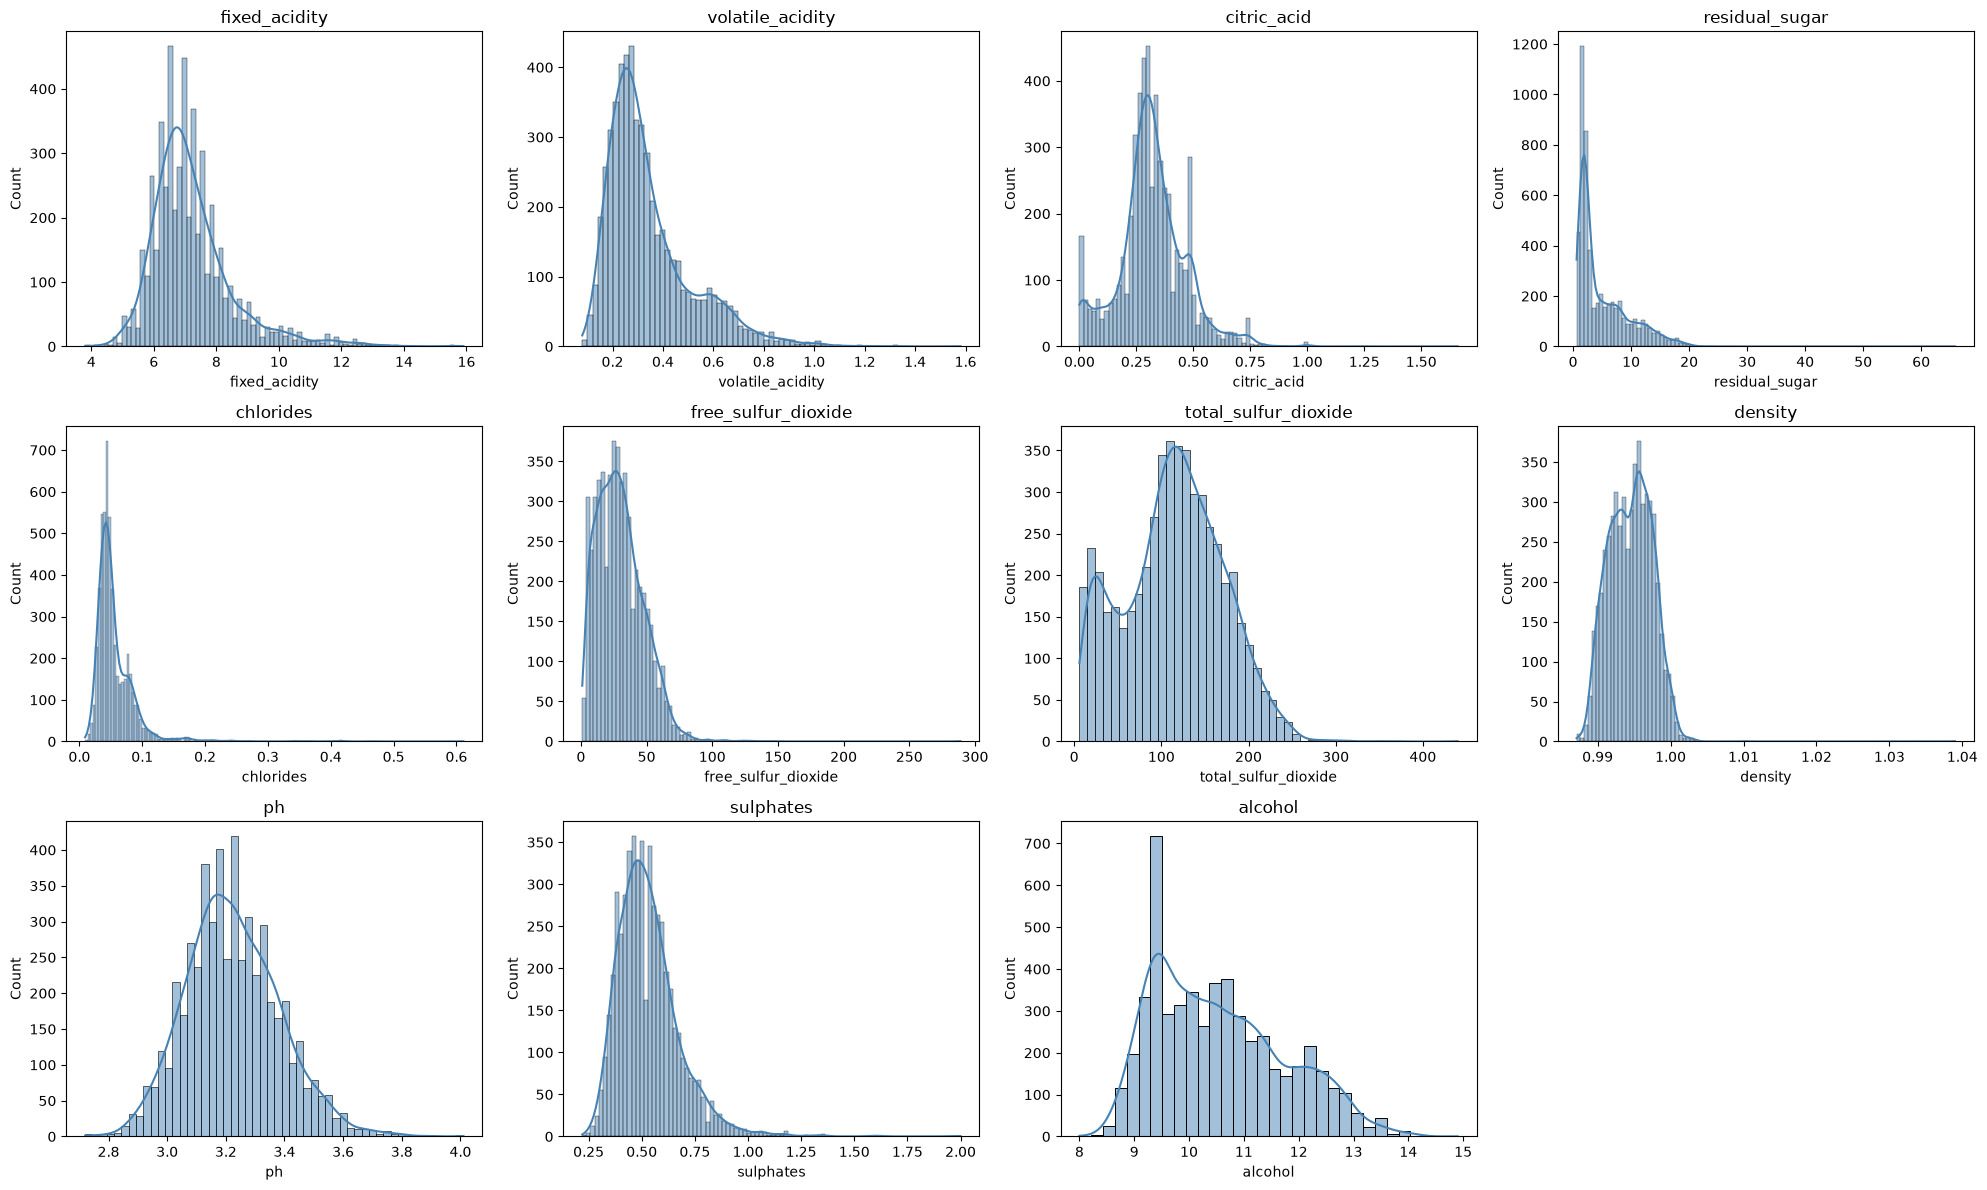

In [2]:
cols_num = [c for c in vin.columns if c not in ("type", "quality")]
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), cols_num):
    sns.histplot(vin[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()


Ce qu’on voit avec les histogrammes :
- alcohol et pH sont plutôt symétriques.
- residual sugar, chlorides, sulfur dioxide et sulphates ont des longues queues à droite.
- Cela indique qu’il peut y avoir des valeurs extrêmes à surveiller.

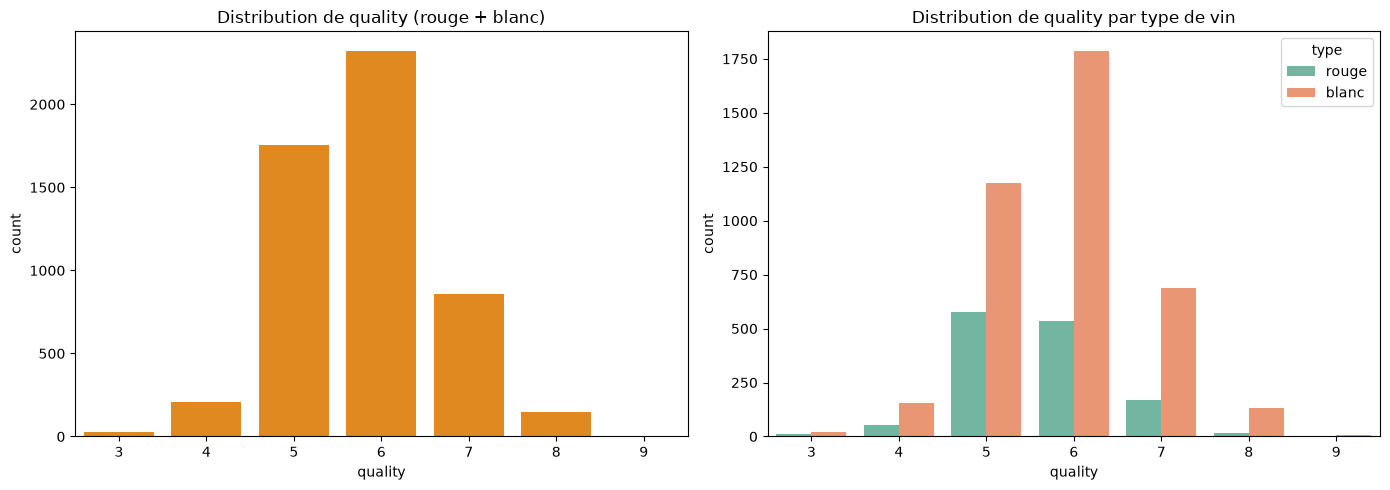

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x="quality", data=vin, color="darkorange", ax=axes[0])
axes[0].set_title("Distribution de quality (rouge + blanc)")

sns.countplot(x="quality", hue="type", data=vin, palette="Set2", ax=axes[1])
axes[1].set_title("Distribution de quality par type de vin")
plt.tight_layout()
plt.show()


Ce qu’on remarque sur `quality` :
- La majorité des notes sont 5, 6 ou 7.
- Les notes 3, 4, 8 et 9 sont rares.

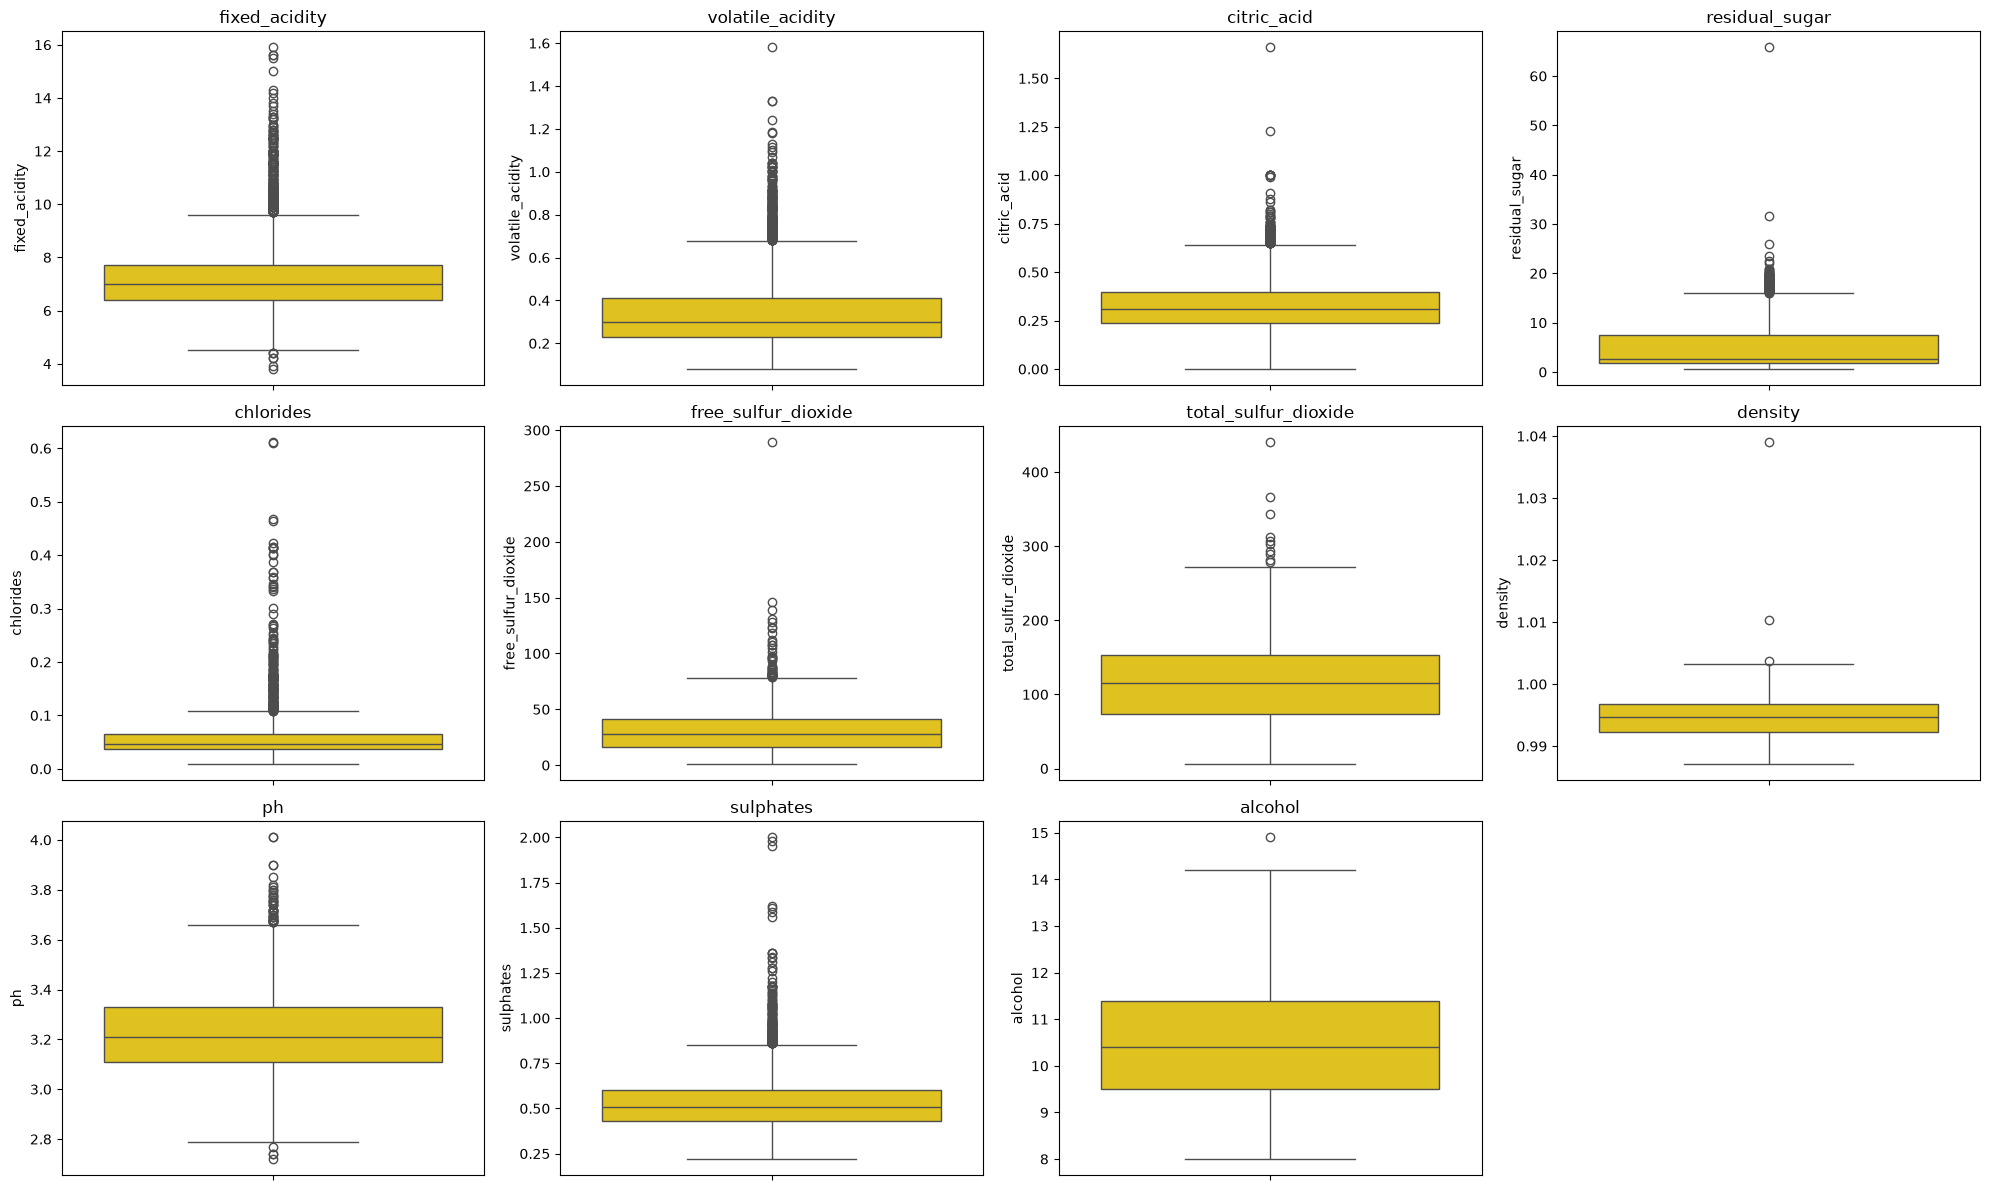

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), cols_num):
    sns.boxplot(y=vin[col], ax=ax, color="gold")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

Plusieurs variables montrent des valeurs très éloignées des autres

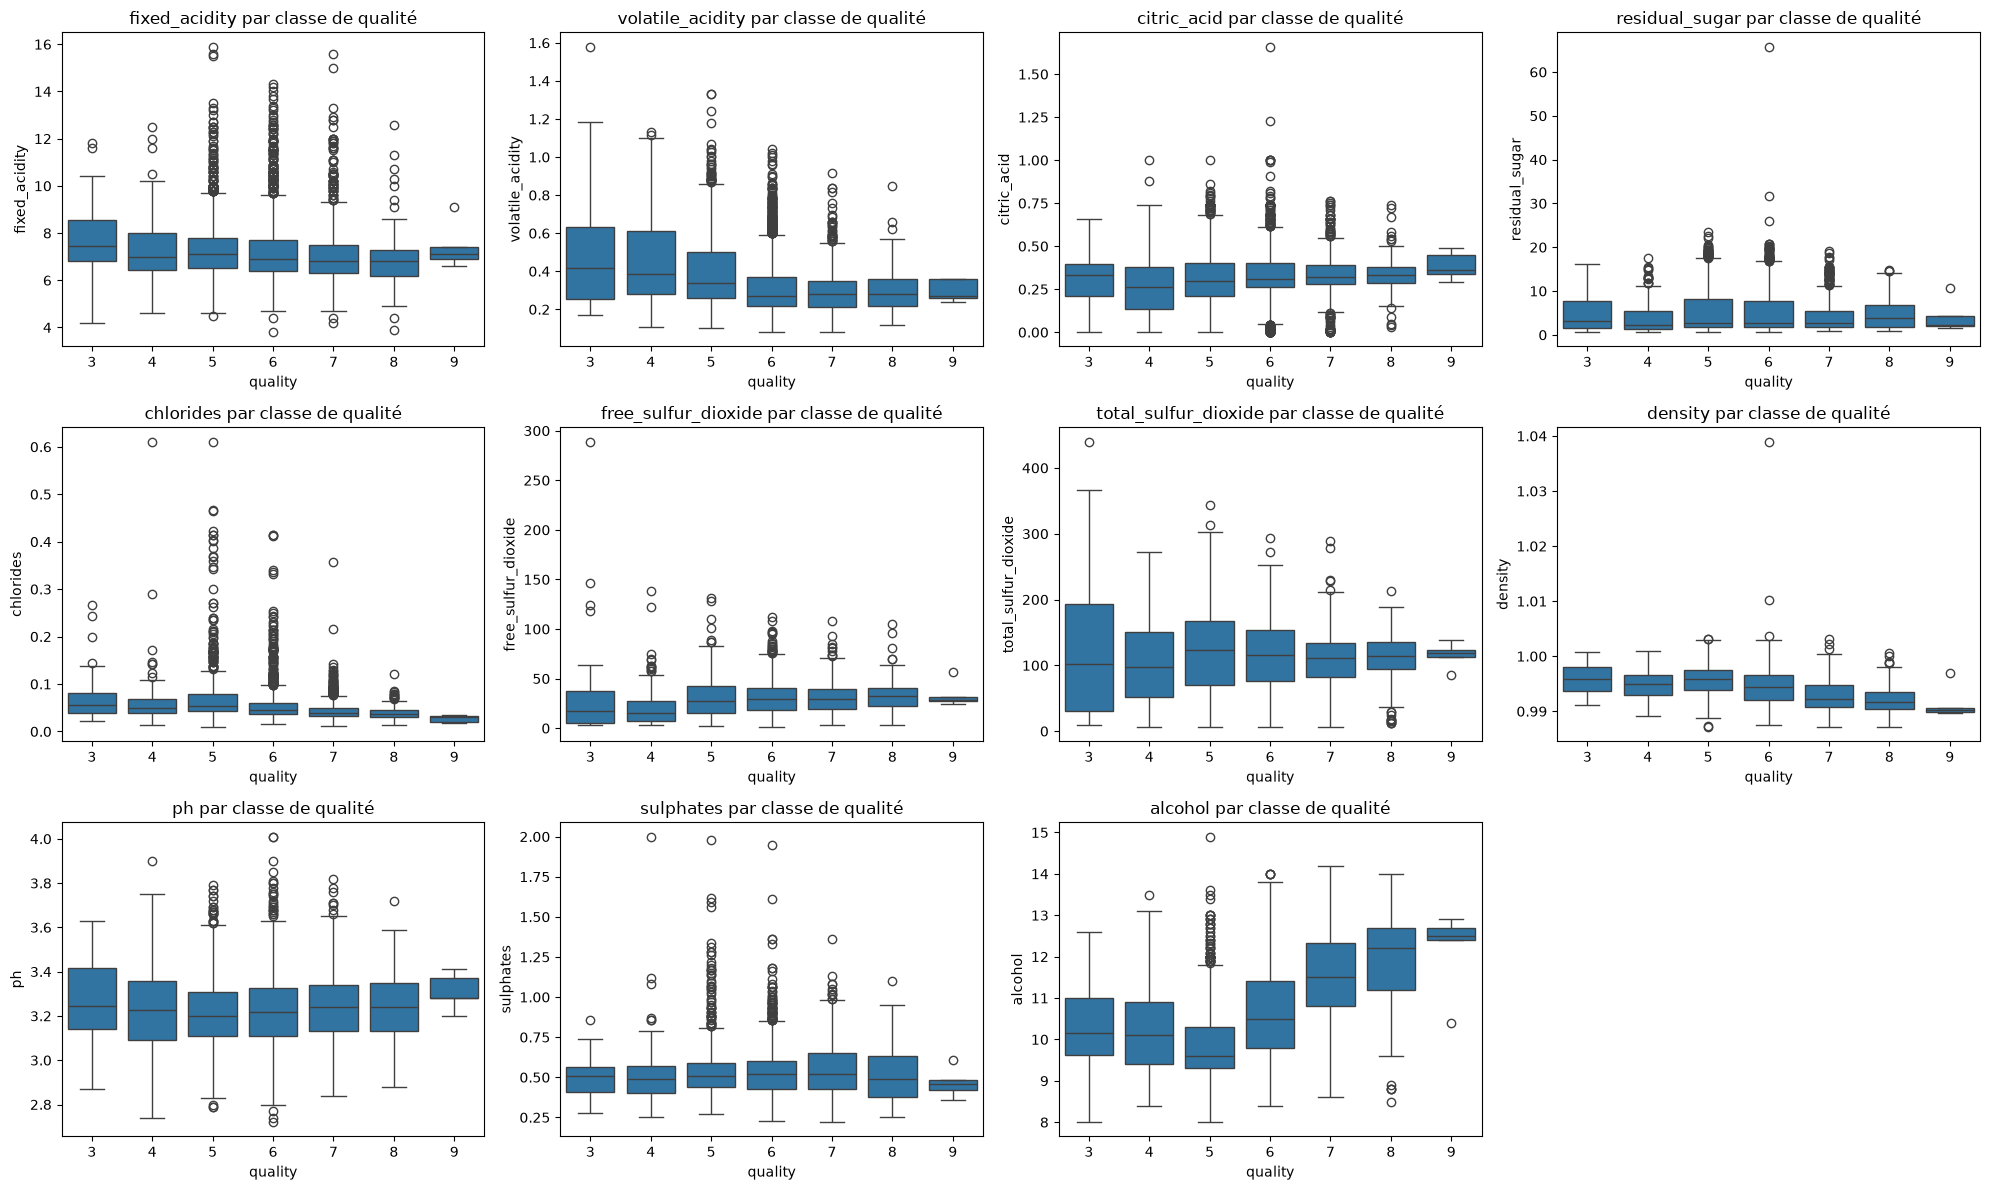

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), cols_num):
    sns.boxplot(x="quality", y=col, data=vin, legend=False, ax=ax)
    ax.set_title(f"{col} par classe de qualité")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

on observe que la plus part des donnée aberante se situe entre la qualite 5,6,7

C:\Users\andri\AppData\Local\Temp\ipykernel_12104\2840980865.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\WINE_QUALITY\venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


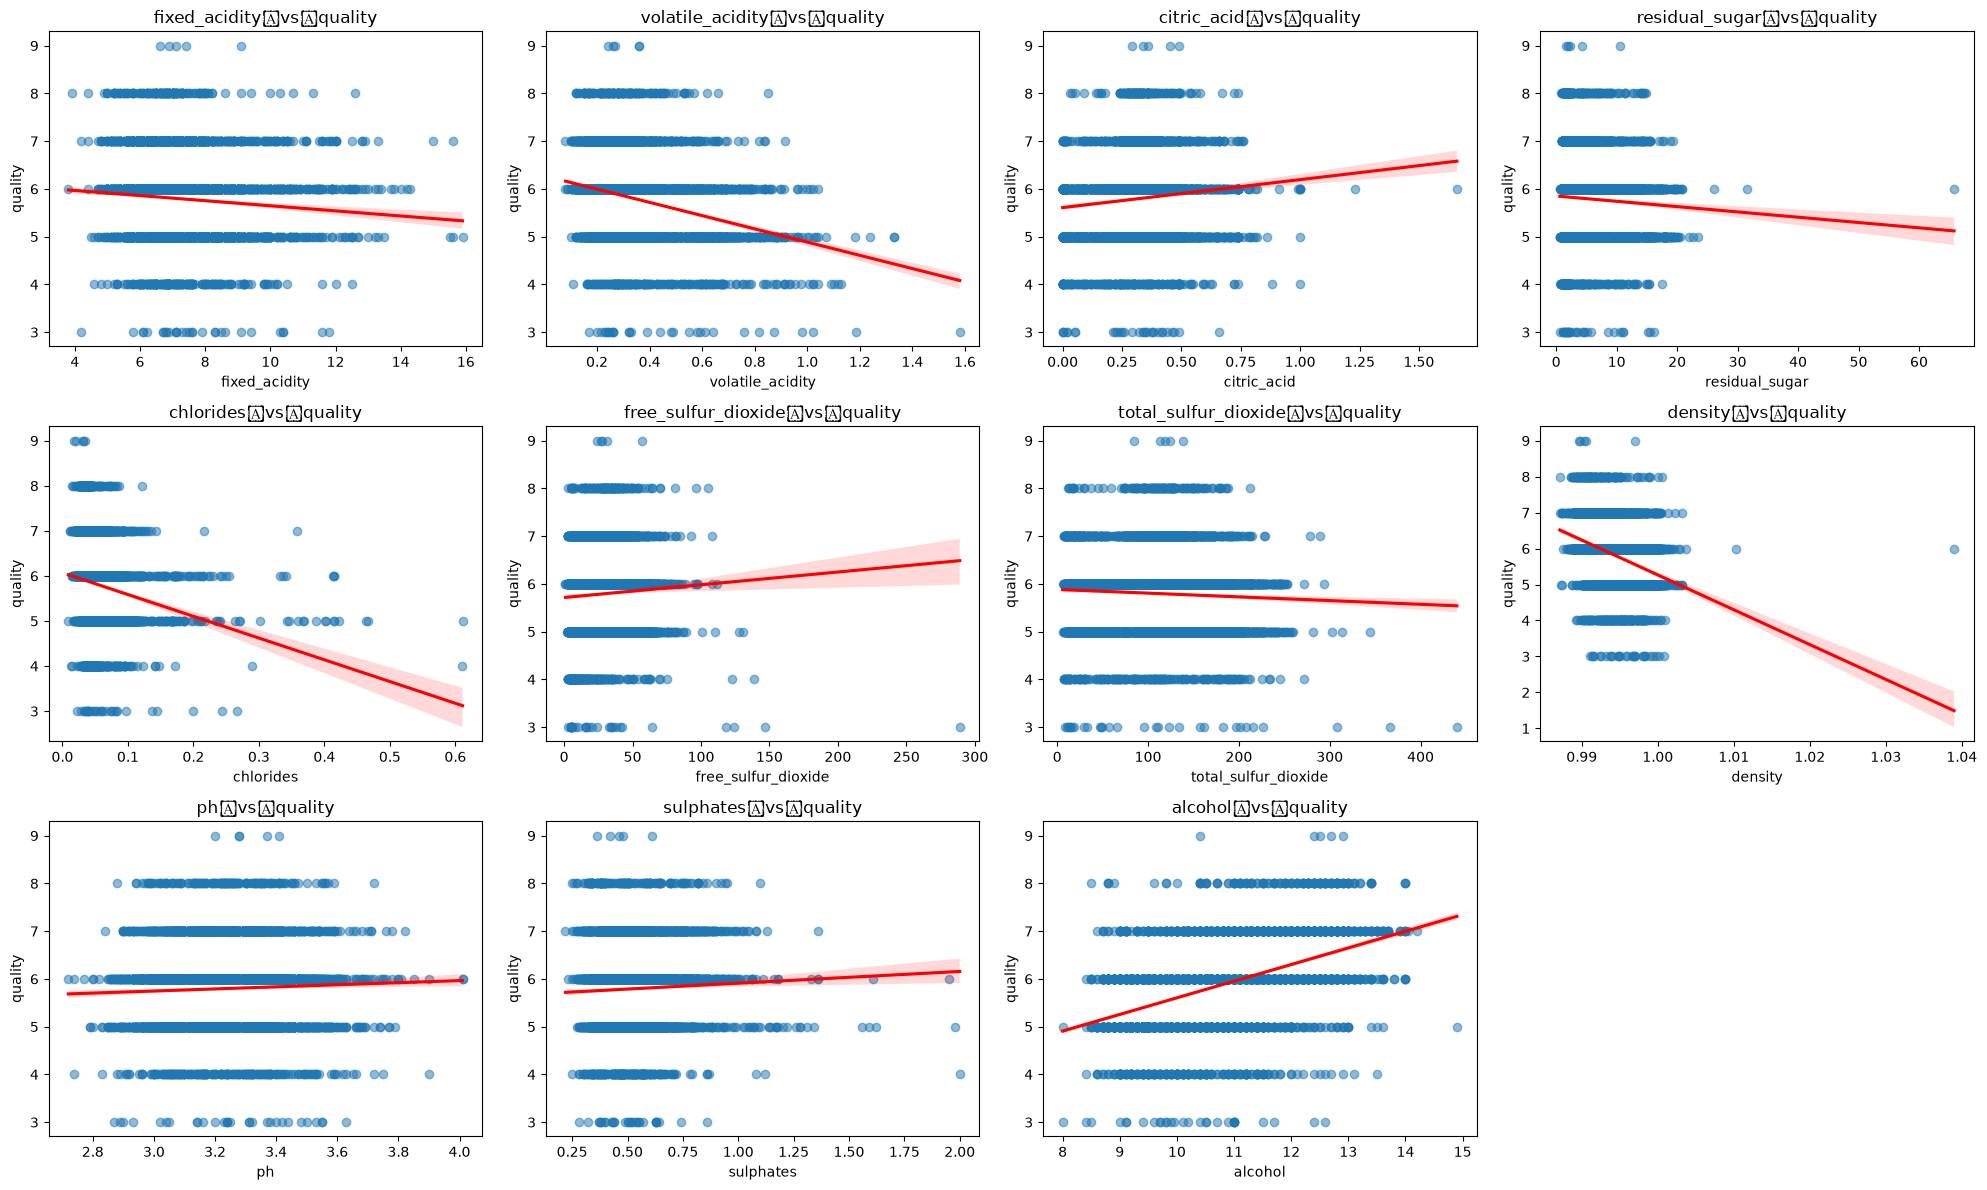

quality                 1.000000
alcohol                 0.469422
citric_acid             0.097954
free_sulfur_dioxide     0.054002
sulphates               0.041884
ph                      0.039733
total_sulfur_dioxide   -0.050296
residual_sugar         -0.056830
fixed_acidity          -0.080092
chlorides              -0.202137
volatile_acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64


In [6]:
cols_num = [c for c in vin.columns if c not in ("type", "quality")]
fig,	axes	=	plt.subplots(3,	4,	figsize=(20,	12)) 
for ax, col in zip(axes.flatten(), cols_num): 
    sns.regplot(x = col,	y = "quality",	data=vin,	ax=ax, 
                scatter_kws={"alpha":	0.5},	line_kws={"color":	"red"})
    ax.set_title(f"{col}	vs	quality") 
axes.flatten()[-1].axis("off")
plt.tight_layout() 
plt.show()
print(vin[cols_num + ["quality"]].corr()["quality"].sort_values(ascending=False))


On observe que plus la quantité d'alcool augmente, plus la qualité du vin est meilleur. On le constate aussi sur le citric_acid mais pas de façon trop evident comme sur l'alcool. Par contre on peut observer que sur la densité, volatile acidity et chlorides plus la quantité, plus le vin est mauvais. 

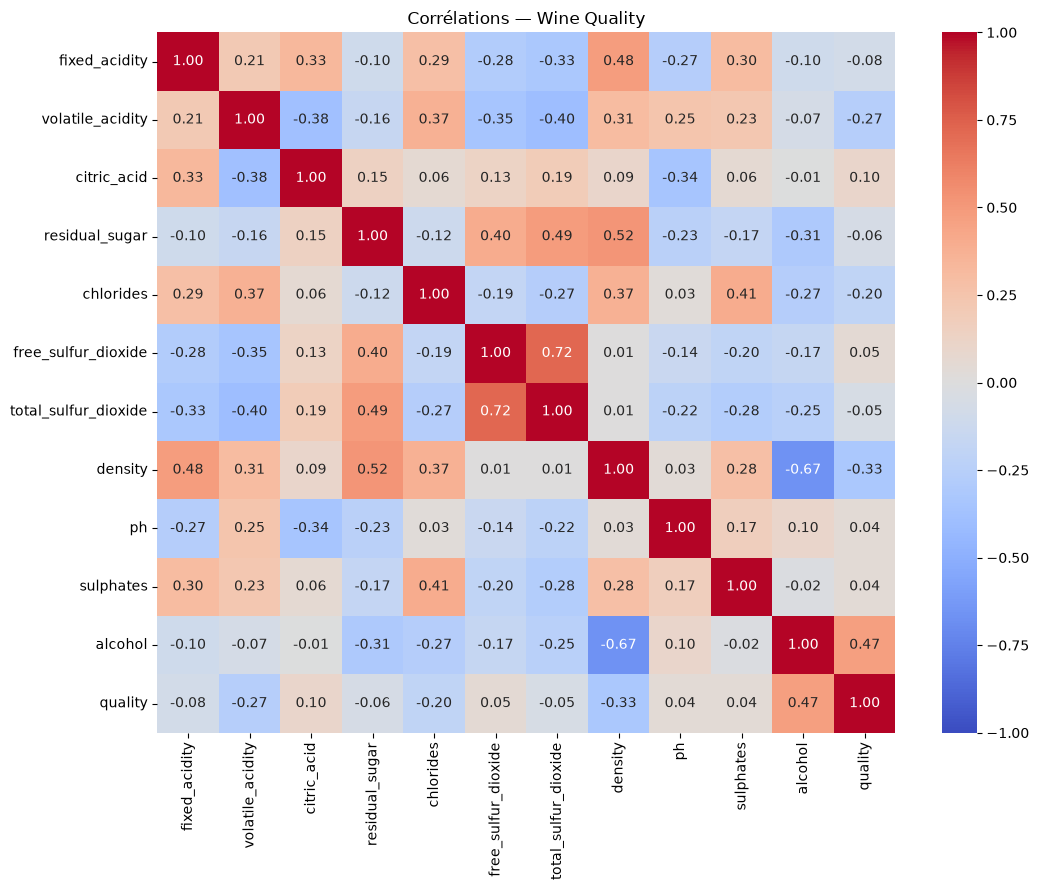

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(vin[cols_num + ["quality"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélations — Wine Quality")
plt.tight_layout()
plt.show()

Deux redondances fortes se démarquent nettement,free sulfur dioxide et total sulfur dioxide (fortement corrélées, 
le SO2 libre étant une composante duSO2 total), et density fortement corrélée (négativement) à alcohol et (positivement) 
à residual sugar. ces paires de variables apportent une information largement redondante. Pour un modèle
linéaire, cela justifierait soit une sélection de variables, soit une PCA en amont ; pour un modèle
d'arbres, la redondance est moins problématique (l'algorithme choisit simplement l'une des deux variables à
chaque split) mais dilue l'importance affichée entre les deux variables corrélées.

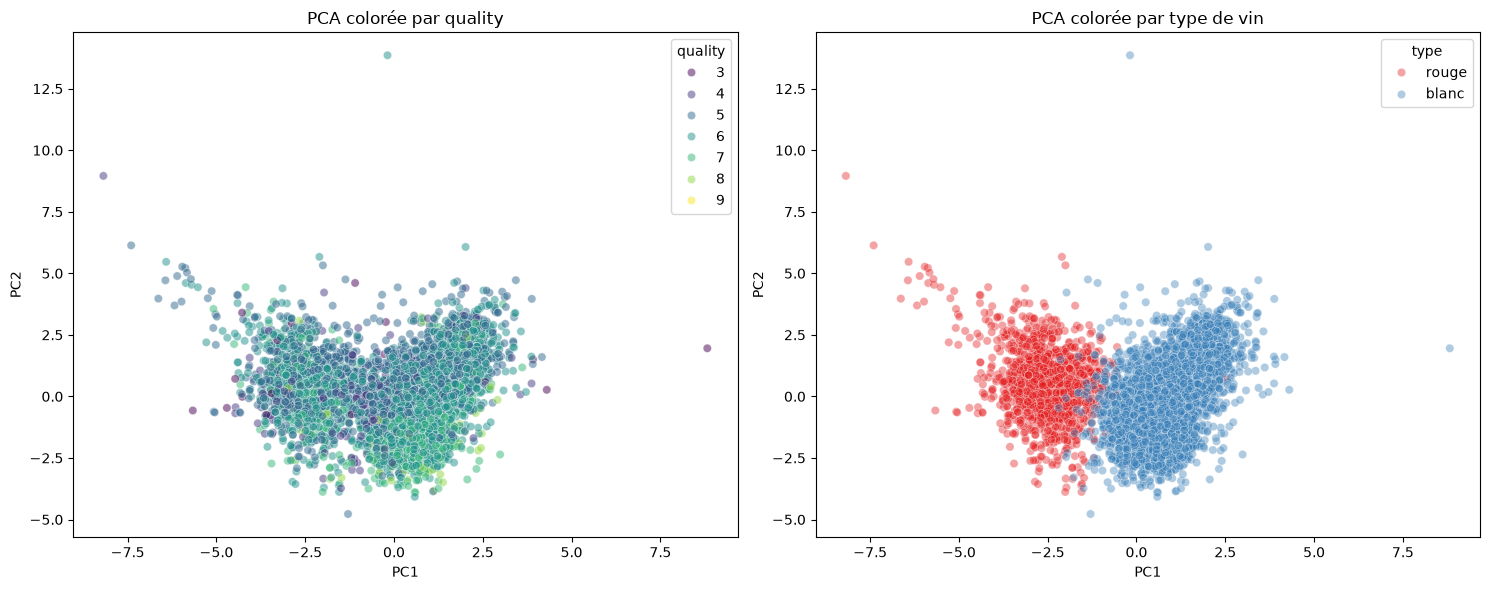

Variance expliquée par les 2 composantes : [0.272 0.225] -> total : 0.497


In [8]:
RANDOM_STATE = 42
X_num = vin[cols_num]
X_scaled = StandardScaler().fit_transform(X_num)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

vin_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
vin_pca["quality"] = vin["quality"].values
vin_pca["type"] = vin["type"].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x="PC1", y="PC2", hue="quality", palette="viridis", data=vin_pca, alpha=0.5, ax=axes[0])
axes[0].set_title("PCA colorée par quality")
sns.scatterplot(x="PC1", y="PC2", hue="type", palette="Set1", data=vin_pca, alpha=0.4, ax=axes[1])
axes[1].set_title("PCA colorée par type de vin")
plt.tight_layout()
plt.show()

print("Variance expliquée par les 2 composantes :", pca.explained_variance_ratio_.round(3),
      "-> total :", round(pca.explained_variance_ratio_.sum(), 3))



- Les points quality sont très mélangés, donc la qualité n’est pas bien séparée en deux dimensions.
- Par contre, type (rouge/blanc) est mieux séparé.
- Cela suggère qu’il faut un modèle capable de gérer des relations plus compliquées que juste deux axes.

In [9]:
def quality_category(x):
    if x <= 5:
        return "Low"
    elif x == 6:
        return "Medium"
    else:
        return "High"


vin["quality_label"] = vin["quality"].apply(quality_category)

In [10]:
vin["quality_label"].value_counts()

quality_label
Medium    2323
Low       1988
High      1009
Name: count, dtype: int64

In [11]:
X = vin.drop(columns=["quality", "quality_label"])
y = vin["quality_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X_train.select_dtypes(include=["object"]).columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_processed, y_train)


y_pred = model.predict(X_test_processed)

print(classification_report(y_test, y_pred))

joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(
    model,
    "../models/random_forest.pkl"
)

C:\Users\andri\AppData\Local\Temp\ipykernel_12104\2215130639.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


              precision    recall  f1-score   support

        High       0.56      0.60      0.58       202
         Low       0.71      0.74      0.73       397
      Medium       0.63      0.59      0.61       465

    accuracy                           0.65      1064
   macro avg       0.63      0.64      0.64      1064
weighted avg       0.65      0.65      0.65      1064



['../models/random_forest.pkl']

Accuracy : 0.6297
F1-score : 0.6245

Classification Report

              precision    recall  f1-score   support

        High       0.58      0.39      0.46       202
         Low       0.70      0.70      0.70       397
      Medium       0.59      0.68      0.63       465

    accuracy                           0.63      1064
   macro avg       0.62      0.59      0.60      1064
weighted avg       0.63      0.63      0.62      1064



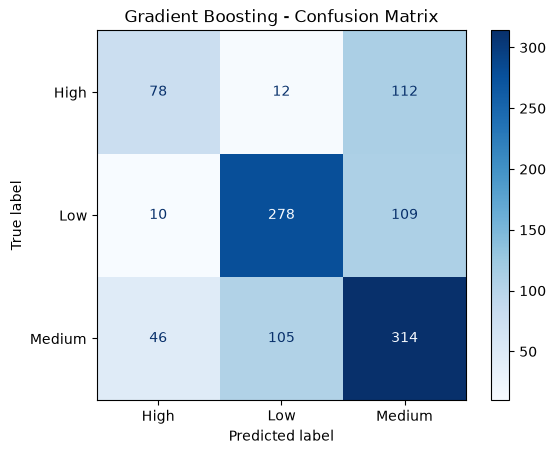

['../models/gradientboost.pkl']

In [12]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)


y_pred = gb_model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=gb_model.classes_
)
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

disp.plot(cmap="Blues")
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()
f1 = f1_score(y_test, y_pred, average="weighted")

joblib.dump(
    gb_model,
    "../models/gradientboost.pkl"
)

In [17]:
# ==============================
# Logistic Regression
# ==============================

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_processed,
    y_train
)

y_pred_lr = lr_model.predict(
    X_test_processed
)

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)


# ==============================
# Random Forest
# ==============================

y_pred_rf = model.predict(
    X_test_processed
)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)


# ==============================
# Gradient Boosting
# ==============================

y_pred_gb = gb_model.predict(
    X_test_processed
)

accuracy_gb = accuracy_score(
    y_test,
    y_pred_gb
)

f1_gb = f1_score(
    y_test,
    y_pred_gb,
    average="weighted"
)


# ==============================
# Tableau comparatif
# ==============================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_gb
    ],
    "F1-score": [
        f1_lr,
        f1_rf,
        f1_gb
    ]
})

comparison

,Model,Accuracy,F1-score
0,Logistic Regression,0.605263,0.598358
1,Random Forest,0.648496,0.647920
2,Gradient Boosting,0.629699,0.624537
